# Explore events
Hillas parameter distributions, image centroids and reconstructed events for a chosen set of telescopes and cuts,
from already processed data (run `process_pff.ipynb` first).

Everything is set in **Selection** below: pick a config, then override any of its telescopes, nights or cuts there to
compare selections without editing the config.

# Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from heap import diagnostics as dg
from heap import events as ev
from heap import significance as sg
from heap.config import load_analysis_config
from heap.parameterize import CAMERA_HALF_WIDTH, TAB10_COLORS
from heap.process_dataset import slugify
from heap.reconstruction import reconstruct_directions
from heap.sources import SOURCES

# Selection

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"]
SOURCE_POSITION = SOURCES.get(SOURCE)

# override any of these, e.g. TELESCOPES = ["Fern", "Winter"] or IMAGE_CUTS = {"width": ("value", 0.3)}
DATES = cfg["source"]["dates"] # None = every night in OUTPUT_DIR with SOURCE
TELESCOPES = cfg["cuts"]["telescopes"] # only these telescopes' images are matched into events; must include REFERENCE
REFERENCE = cfg["events"]["reference"]
MIN_TEL = cfg["cuts"]["min_tel"]
MIN_NPIX = cfg["cuts"]["min_npix"]
IMAGE_CUTS = cfg["cuts"]["image_cuts"] # {column: (mode, threshold)}, see heap.events.apply_cut()

# event building
COINC_WINDOW = cfg["events"]["coinc_window"]
ROTATE_POSTFLIP = cfg["events"]["rotate_postflip"]
REL_TEL_EFFICIENCY = cfg["events"]["rel_tel_efficiency"]
POINTING_CORRECTIONS = cfg["events"]["pointing_corrections"]
POINTING_OVERRIDES = cfg["source"]["pointing_overrides"]

# plotting
N_EVENTS = 4 # reconstructed events to display
PLOT_RADIUS = 3 # deg from the camera center for the direction histogram
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

In [3]:
if DATES is None:
    products = dg.product_table(OUTPUT_DIR)
    DATES = sorted(products[products.Source == slugify(SOURCE, sep="_")].Date.unique())
print(f"{SOURCE}, nights {DATES}, telescopes {TELESCOPES} (reference {REFERENCE})")
print(f"cuts: min_tel {MIN_TEL}, min_npix {MIN_NPIX}, image cuts {IMAGE_CUTS}")

Crab, nights ['20260917', '20260918', '20260922'], telescopes ['Heli', 'Fern', 'Winter', 'Gattini'] (reference Winter)
cuts: min_tel 2, min_npix 3, image cuts {'width': ('nsigma', 0.5)}


# Events
Images of `TELESCOPES` matched into array events within `COINC_WINDOW` after correcting timestamps against `REFERENCE`
(`heap.events.build_array_events()`), then the cuts (`heap.events.apply_cuts()`).

In [4]:
dfs = []
for date in DATES:
    night = ev.build_array_events(
        OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES, REFERENCE, window=COINC_WINDOW,
        rotate_postflip=ROTATE_POSTFLIP, rel_tel_efficiency=REL_TEL_EFFICIENCY, pointing_corrections=POINTING_CORRECTIONS,
    )
    if night is None or len(night) == 0:
        print(f"{date}: no {SOURCE} events")
        continue
    night["Event"] += dfs[-1].Event.max() + 1 if dfs else 0 # unique across nights
    dfs.append(night)
df = pd.concat(dfs, ignore_index=True)
array = ev.apply_cuts(df, min_tel=MIN_TEL, min_npix=MIN_NPIX, telescopes=TELESCOPES, cuts=IMAGE_CUTS)
print(f"{df.Event.nunique()} events ({len(df)} images) before cuts, {array.Event.nunique()} events ({len(array)} images) after")

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packag

Winter-Heli timing offset: RMS=  0.00042 s, std= 0.00042 s
Winter-Heli corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Fern timing offset: RMS=  8e-05 s, std= 5e-05 s
Winter-Fern corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Gattini timing offset: RMS=  0.00106 s, std= 0.00104 s
Winter-Gattini corrected offset: RMS=  0.00131 s, std= 0.00128 s
Heli-Fern within 0.001s: 4293/11106 Heli events (38.7%) and 4290/10503 Fern events (40.8%) coincident, 4312 pairs
Heli-Winter within 0.001s: 3526/11106 Heli events (31.7%) and 3457/13797 Winter events (25.1%) coincident, 4193 pairs
Heli-Gattini within 0.001s: 517/11106 Heli events (4.7%) and 443/10912 Gattini events (4.1%) coincident, 554 pairs
Fern-Winter within 0.001s: 3144/10503 Fern events (29.9%) and 3144/13797 Winter events (22.8%) coincident, 3159 pairs
Fern-Gattini within 0.001s: 244/10503 Fern events (2.3%) and 244/10912 Gattini events (2.2%) coincident, 245 pairs
Winter-Gattini within 0.001s: 481/13797 Winter events (3.5%) and 460/10

In [5]:
# events per telescope combination before cuts, and how many of them still have MIN_TEL+ images after cuts
combo = df.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t)))
n_images = array.Event.value_counts()
kept = combo.index.isin(n_images[n_images >= MIN_TEL].index)
pd.DataFrame({"before cuts": combo.value_counts(), "after cuts": combo[kept].value_counts()}).fillna(0).astype(int)

,before cuts,after cuts
Telescope,,
Fern + Gattini,53,16
Fern + Gattini + Heli,39,35
Fern + Gattini + Heli + Winter,298,247
Fern + Gattini + Winter,11,8
Fern + Heli,6113,3677
Fern + Heli + Winter,6059,4223
Fern + Winter,2366,1597
Gattini + Heli,217,120
Gattini + Heli + Winter,185,165


# Hillas parameters
One line per telescope, all telescopes pooled filled in grey.

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


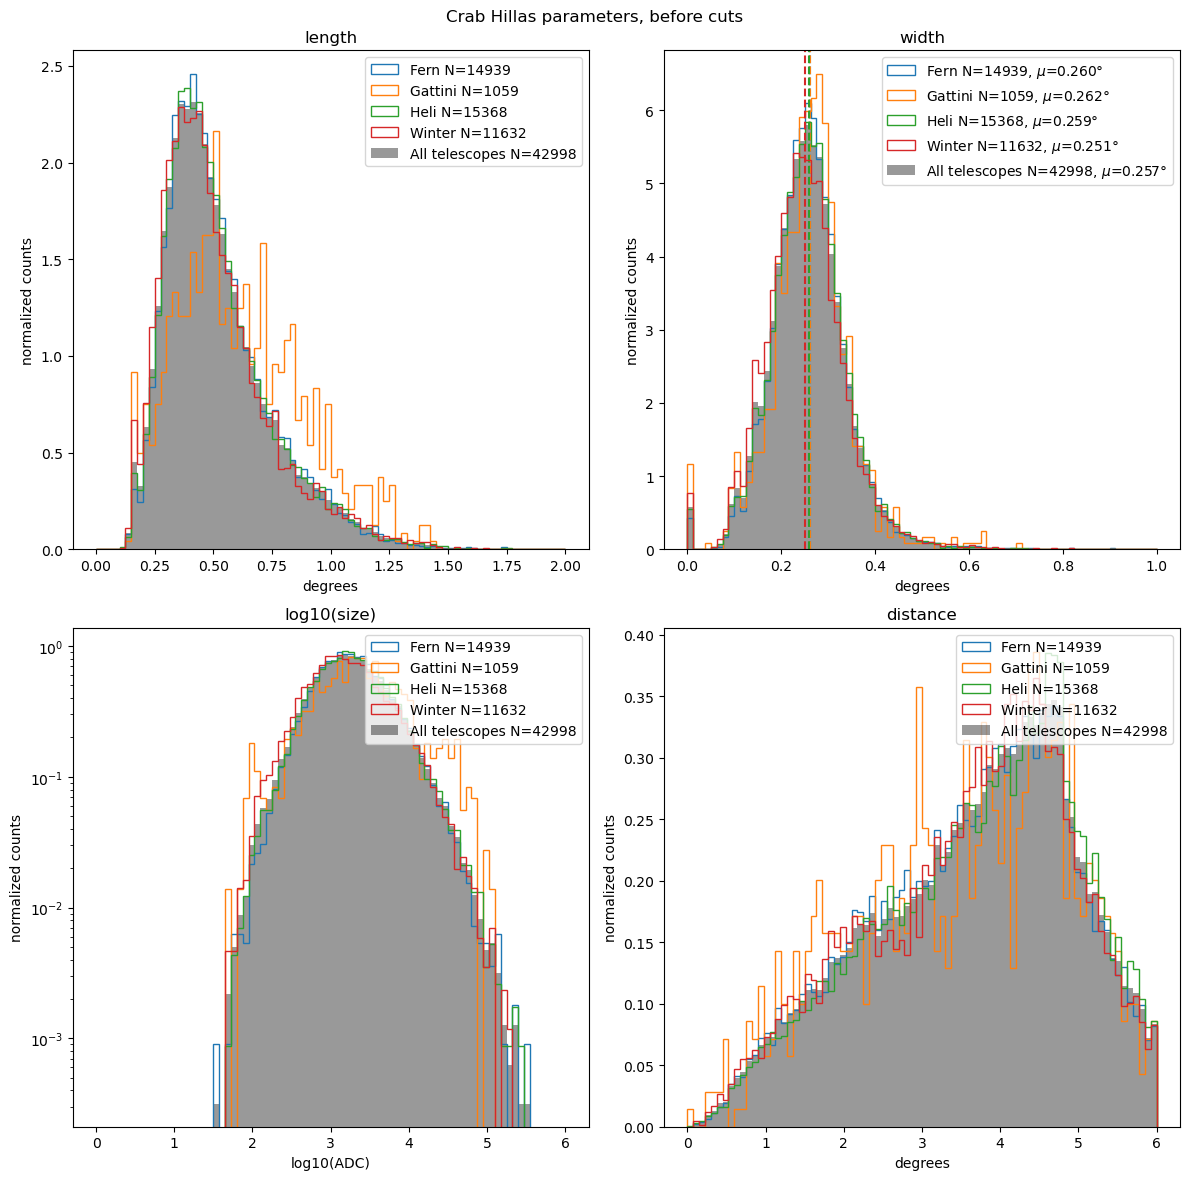

In [6]:
ev.plot_hillas(df, f"{SOURCE} Hillas parameters, before cuts", colors=COLORS)
plt.show()

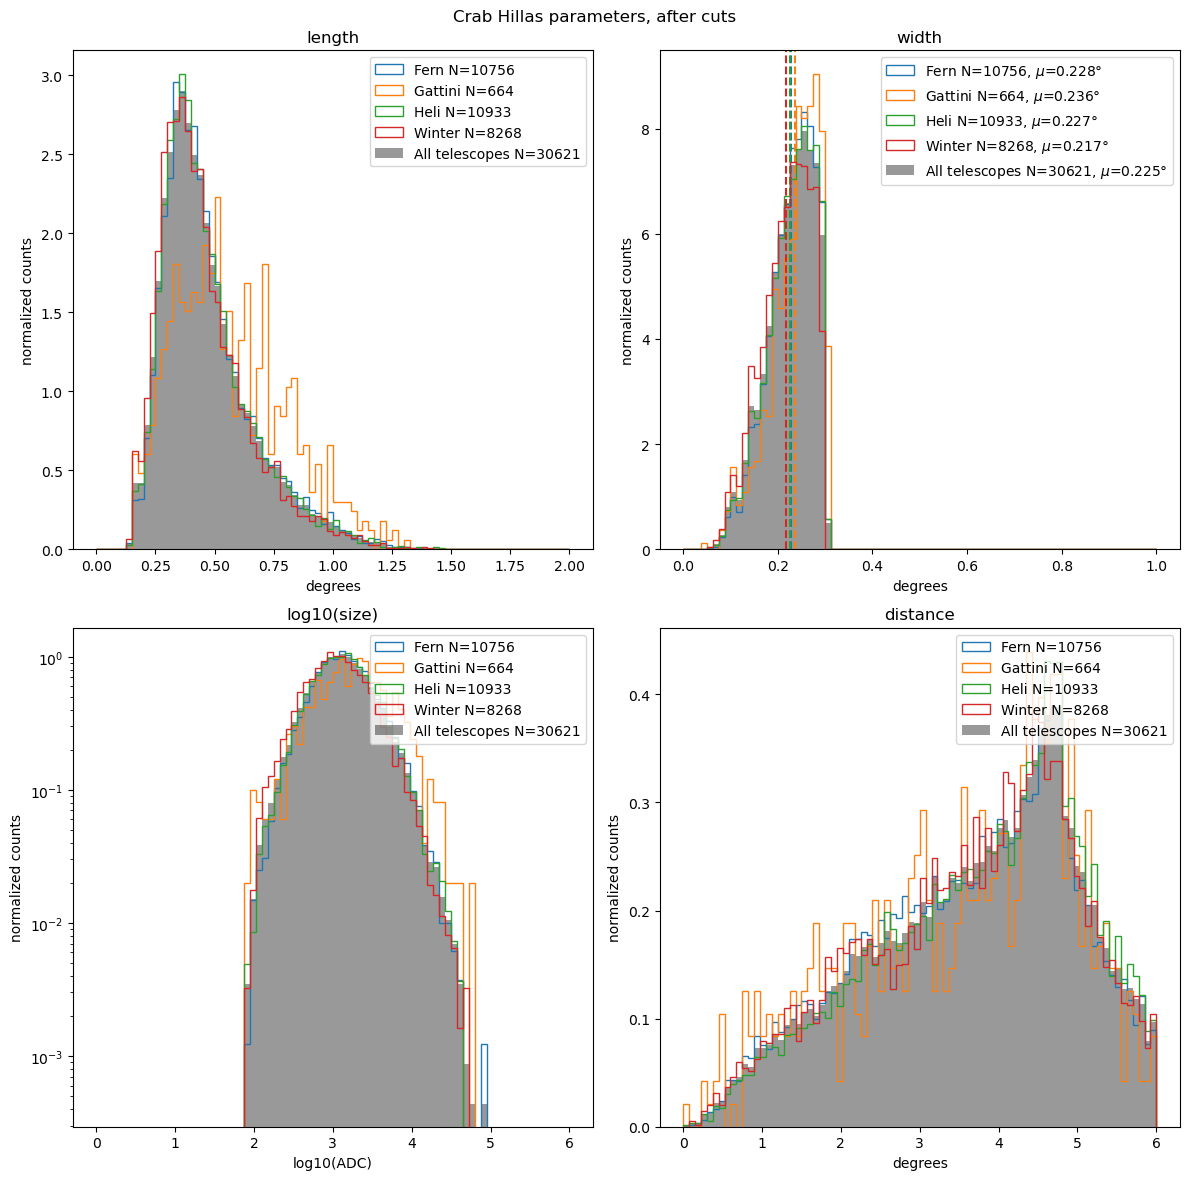

In [7]:
ev.plot_hillas(array, f"{SOURCE} Hillas parameters, after cuts", colors=COLORS)
plt.show()

In [8]:
array.groupby("Telescope")[["N_pix", "size", "length", "width", "distance", "alpha"]].describe().T

Telescope               Fern       Gattini          Heli        Winter
N_pix    count  10756.000000    664.000000  10933.000000   8268.000000
         mean      19.287653     24.378012     18.847251     17.163885
         std       11.134101     14.452299     11.020492     10.574458
         min        3.000000      3.000000      3.000000      3.000000
         25%       11.000000     14.000000     11.000000     10.000000
         50%       17.000000     22.000000     17.000000     15.000000
         75%       25.000000     32.000000     24.000000     22.000000
         max       93.000000     89.000000     93.000000     91.000000
size     count  10756.000000    664.000000  10933.000000   8268.000000
         mean    2148.113160   3244.462884   2119.919660   1826.600926
         std     2803.038610   4797.807285   2766.640986   2570.996647
         min       85.724435     77.867426     77.067131     87.321701
         25%      751.060286    856.172941    724.880466    601.677602
         50%     1344.055159   1838.485023   1324.832186   1095.568393
         75%     2467.774682   3645.972253   2427.147687   2055.572556
         max    77776.130214  59740.044843  43350.821824  51905.968754
length   count  10756.000000    664.000000  10933.000000   8268.000000
         mean       0.474269      0.564426      0.468621      0.451902
         std        0.194870      0.236114      0.193393      0.190448
         min        0.124425      0.151700      0.137258      0.127674
         25%        0.337757      0.381331      0.333939      0.317688
         50%        0.427869      0.521384      0.423956      0.410187
         75%        0.565603      0.720610      0.558230      0.543395
         max        1.726045      1.307351      1.597389      2.076431
width    count  10756.000000    664.000000  10933.000000   8268.000000
         mean       0.228058      0.235831      0.226656      0.217331
         std        0.048204      0.051319      0.049793      0.051392
         min        0.059689      0.044809      0.053042      0.053791
         25%        0.197290      0.205225      0.195106      0.183045
         50%        0.235393      0.247755      0.234371      0.224713
         75%        0.266035      0.275869      0.266427      0.258911
         max        0.301291      0.307619      0.301227      0.295983
distance count  10756.000000    664.000000  10933.000000   8268.000000
         mean       3.693457      3.679175      3.845282      3.698415
         std        1.365870      1.430679      1.357859      1.365356
         min        0.138083      0.058699      0.017096      0.089623
         25%        2.695144      2.643141      2.891406      2.720958
         50%        3.876491      3.926181      4.049474      3.887809
         75%        4.711159      4.733317      4.818974      4.703479
         max        6.658208      6.494158      6.635298      6.650369
alpha    count  10756.000000    664.000000  10933.000000   8268.000000
         mean      44.246864     47.669824     44.815373     42.991559
         std       26.086098     25.153884     26.029174     26.039779
         min        0.004867      0.060561      0.019069      0.019014
         25%       21.523604     27.615855     21.748228     20.335650
         50%       44.597611     47.830583     45.698473     41.981145
         75%       66.392869     68.752629     66.996527     65.075792
         max       89.996598     89.801030     89.998563     89.982117

# Image centroids
Centroids (`x_c`, `y_c`) in the camera frame, one bin per pixel: postflip images rotated into the preflip frame, where
+x points east and +y south (see `heap.significance.make_wcs()`).

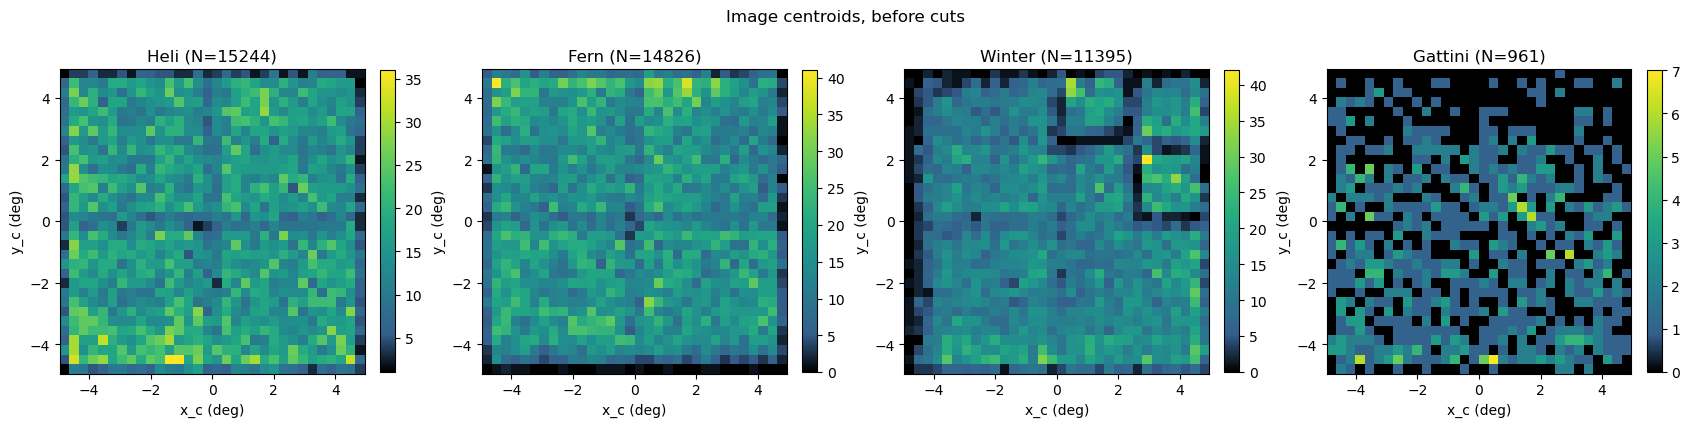

In [9]:
dg.plot_centroids(df, "Image centroids, before cuts", telescopes=TELESCOPES)
plt.show()

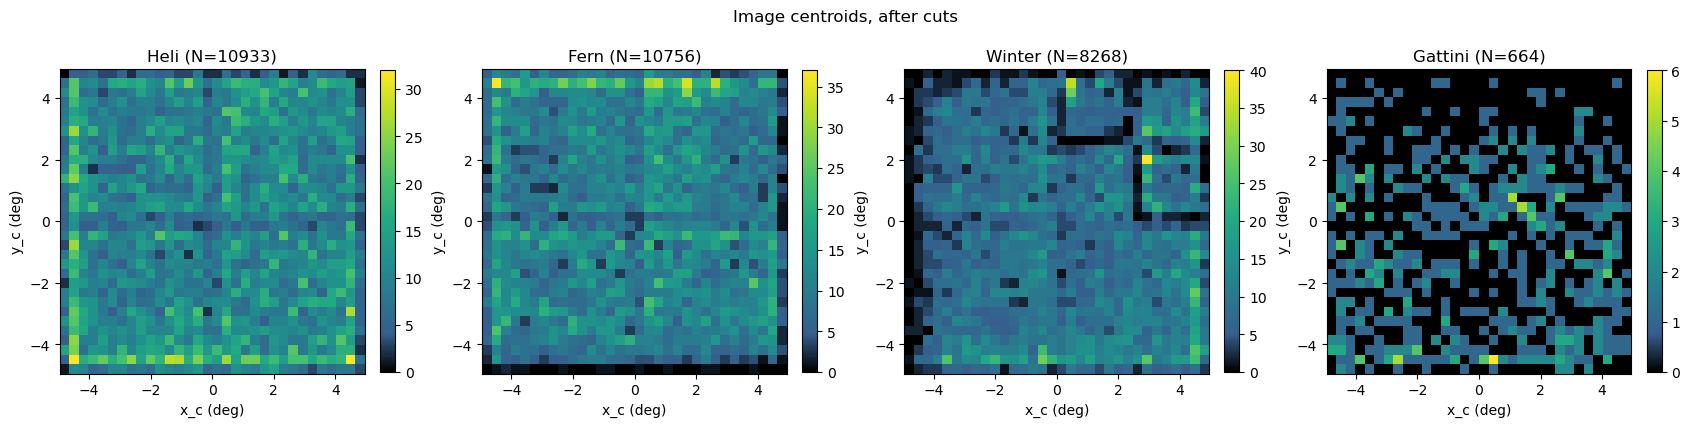

In [10]:
dg.plot_centroids(array, "Image centroids, after cuts", telescopes=TELESCOPES)
plt.show()

## All images
Every image of `TELESCOPES`, coincident or not (`heap.events.load_camera_frames()`), with the image cuts but no
`MIN_TEL`. `"nsigma"` cut thresholds are over all images here, so they differ from the array events' above.

In [ ]:
frames = []
for date in DATES:
    night, _ = ev.load_camera_frames(
        OUTPUT_DIR, RAW_DATA_DIR / date, date, SOURCE, TELESCOPES,
        rotate_postflip=ROTATE_POSTFLIP, rel_tel_efficiency=REL_TEL_EFFICIENCY, pointing_corrections=POINTING_CORRECTIONS,
    )
    frames += night.values()
images = pd.concat(frames, ignore_index=True)
images["Event"] = images.index # each image its own event, so apply_cuts() needs min_tel=1
images_cut = ev.apply_cuts(images, min_tel=1, min_npix=MIN_NPIX, telescopes=TELESCOPES, cuts=IMAGE_CUTS)
print(f"{len(images)} images before cuts, {len(images_cut)} after")

In [ ]:
dg.plot_centroids(images, "Image centroids, all images, before cuts", telescopes=TELESCOPES)
plt.show()

In [ ]:
dg.plot_centroids(images_cut, "Image centroids, all images, after cuts", telescopes=TELESCOPES)
plt.show()

## Event display
Each image of an event, then all its Hillas ellipses together. Run the cell again for other events.

In [11]:
# arrival directions (heap.reconstruction) and each run's pointing, for the source position in plot_event()
directions = reconstruct_directions(array)
pointings = {}
for date in directions.Date.unique():
    pointings |= ev.run_pointings(ev.source_runs(RAW_DATA_DIR / date, REFERENCE, SOURCE), REFERENCE)
pointings |= POINTING_OVERRIDES
print(f"{len(directions)} reconstructed events")

11881 reconstructed events


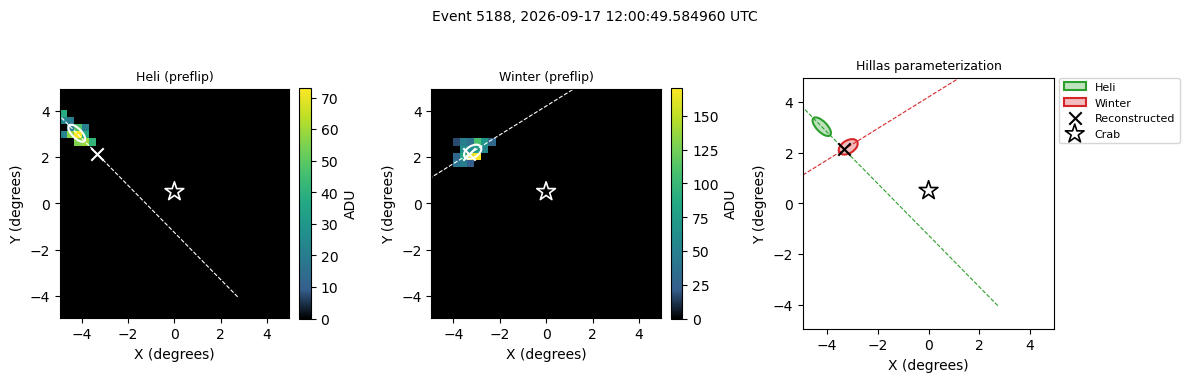

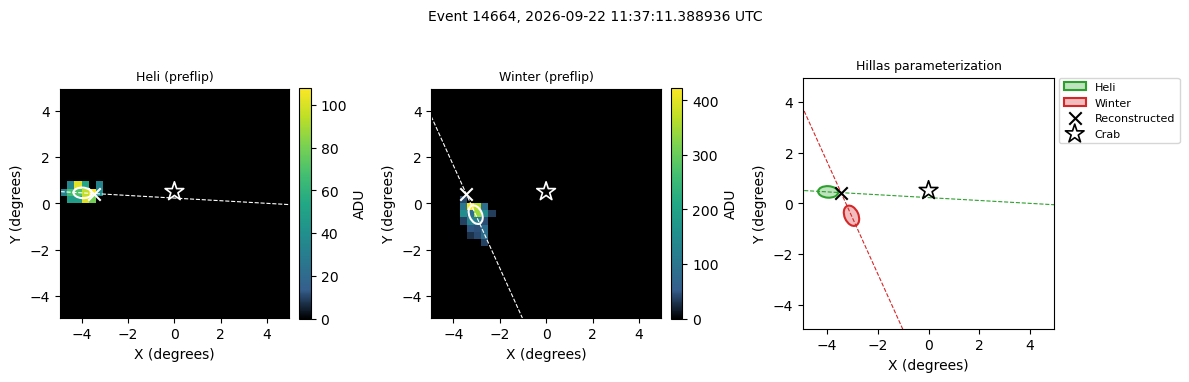

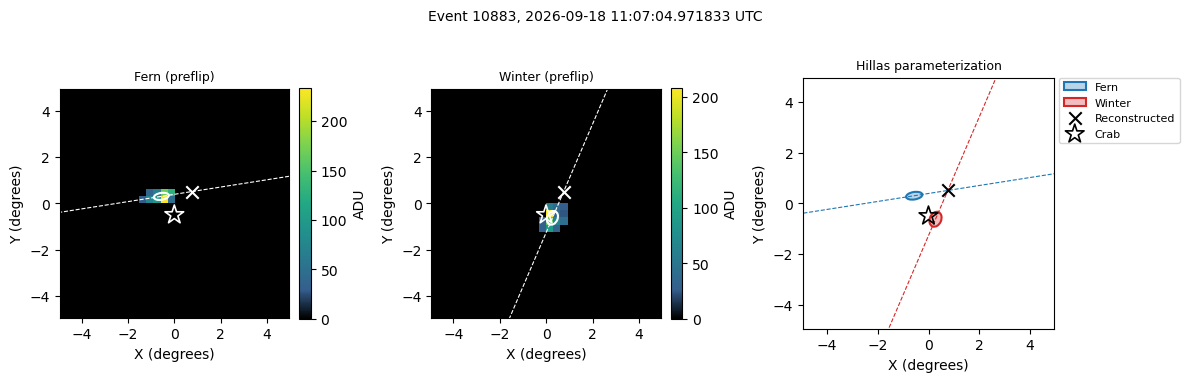

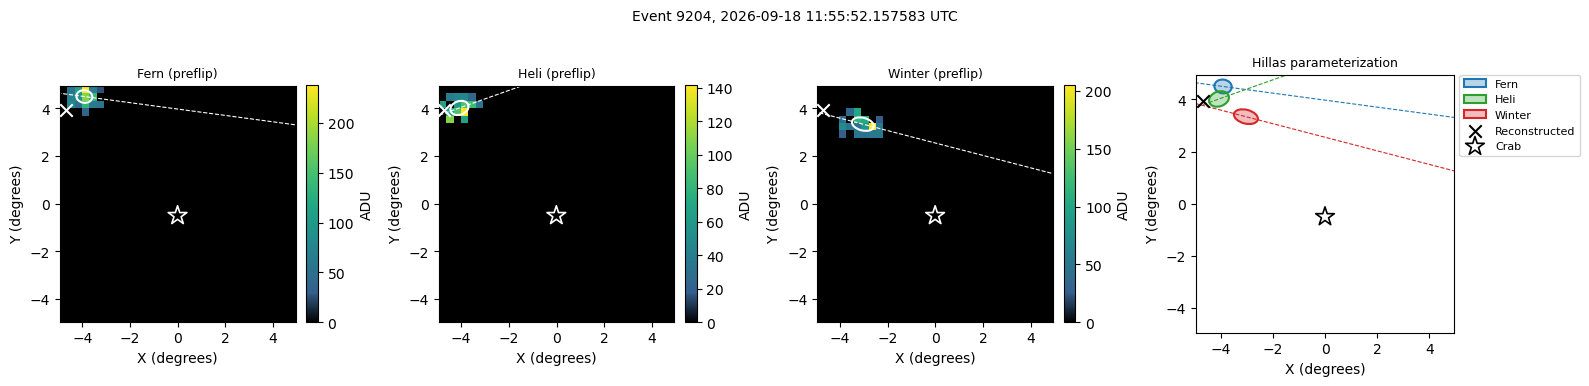

In [12]:
for e in np.random.default_rng().choice(directions.Event, size=min(N_EVENTS, len(directions)), replace=False):
    ev.plot_event(
        array[array.Event == e], directions[directions.Event == e].iloc[0], OUTPUT_DIR, SOURCE,
        source_position=SOURCE_POSITION, pointings=pointings, colors=COLORS,
        rotate_postflip=ROTATE_POSTFLIP, pointing_corrections=POINTING_CORRECTIONS,
    )
    plt.show()